In [1]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:

def image_grid(shape, recenter:bool = False):
    ny, nx = shape
    cy, cx = (0,0)
    if recenter:
        cy, cx = ny//2, nx//2
    x = np.arange(nx, dtype=float) - cx
    y = np.arange(ny, dtype=float) - cy
    X,Y = np.meshgrid(x, y)
    return X,Y

def get_photocenter(image,offset:bool=False):
    X,Y = image_grid(image.shape)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    if offset:
        qy += 0.5
        qx += 0.5
    return qx,qy 

def get_frame_pupil_centers(frame,thr=0.3,xhalf=100,yhalf=120):
    Y,X = image_grid(frame.shape)
    ll = (X<=xhalf) * (Y<=yhalf)
    lr = (X>xhalf) * (Y<=yhalf)
    ul = (X<=xhalf) * (Y>yhalf)
    ur = (X>xhalf) * (Y>yhalf)
    centers = np.zeros([4,2])
    mask = (frame*ll > thr*np.nanmax(frame*ll)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[0,:] = np.array([qx,qy])
    mask = (frame*lr > thr*np.nanmax(frame*lr)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[1,:] = np.array([qx,qy])
    mask = (frame*ul > thr*np.nanmax(frame*ul)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[2,:] = np.array([qx,qy])
    mask = (frame*ur > thr*np.nanmax(frame*ur)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[3,:] = np.array([qx,qy])
    return centers

[[-34.82729433 -29.13370402]
 [-33.43978634  28.66589045]
 [ 34.51930124 -31.13193683]
 [ 33.74777943  31.59975039]]


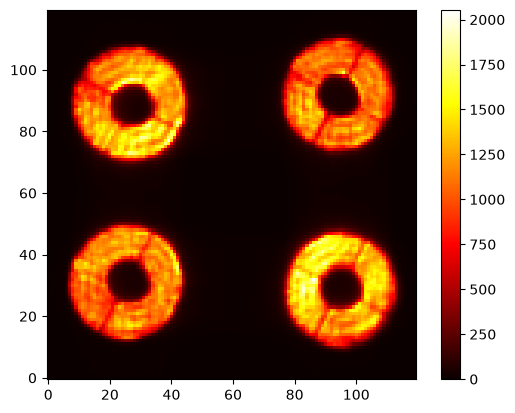

In [3]:
img = np.load('/raid1/mmenessini/calibration/EKARUS/data/OnSky_frame.npy')

ref_centers = get_frame_pupil_centers(img)
avg_center = np.mean(ref_centers,axis=0)
ref_dcenters = ref_centers-avg_center
print(ref_dcenters)

xmin = int(np.round(avg_center[0]))-60
xmax = int(np.round(avg_center[0]))+60
ymin = int(np.round(avg_center[1]))-60
ymax = int(np.round(avg_center[1]))+60

img = img[ymin:ymax,xmin:xmax]

plt.figure()
plt.imshow(img,origin='lower',cmap='hot')
plt.colorbar()

[[ 0.1323696   0.07777543]
 [ 0.22933749  0.38286338]
 [-0.08513652 -0.16183812]
 [-0.27657057 -0.29880069]]


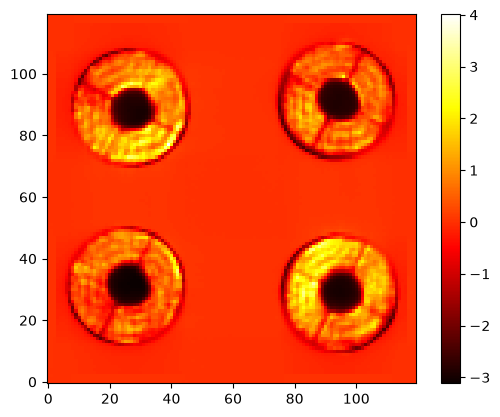

In [ ]:
frame = fits.getdata('/raid1/mmenessini/results/EKARUS/frame.fits')[0,60:180,60:180]

centers = get_frame_pupil_centers(frame,xhalf=60,yhalf=60)
dcenters = centers-np.mean(centers,axis=0)
tilt_coeffs = ref_dcenters.T/30
print(dcenters-ref_dcenters)

plt.figure()
plt.imshow(frame,origin='lower',cmap='hot',vmax=200)
plt.imshow(img/np.mean(img)-frame/np.mean(frame),origin='lower',cmap='hot')
plt.colorbar()

In [ ]:
from specula.mmlib.utils import get_pupil_mask

pyr_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')[60:180,60:180]
sky_pyr_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')[60:180,60:180]


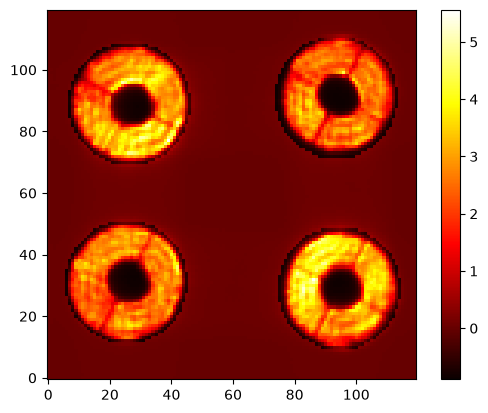

In [80]:
plt.figure()
plt.imshow(img/np.mean(img)-pyr_mask,origin='lower',cmap='hot')
plt.colorbar()

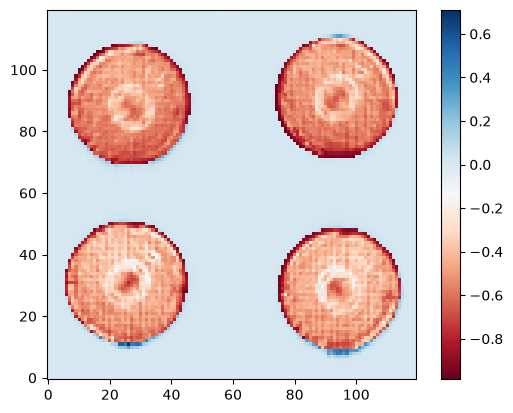

In [ ]:
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260729_122235.fits')

imframe = im[:,290].reshape([240,240])
imframe = np.std(im,axis=1).reshape([240,240])

ref_centers = get_frame_pupil_centers(imframe)
savg_center = np.mean(ref_centers,axis=0)

xsmin = int(np.round(savg_center[0]))-60
xsmax = int(np.round(savg_center[0]))+60
ysmin = int(np.round(savg_center[1]))-60
ysmax = int(np.round(savg_center[1]))+60

frimg = imframe[ysmin:ysmax,xsmin:xsmax]

# np.save('/raid1/mmenessini/calibration/EKARUS/data/OnBench_frame.npy',imframe)

plt.figure()
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
# plt.imshow(frame/np.max(frame)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()

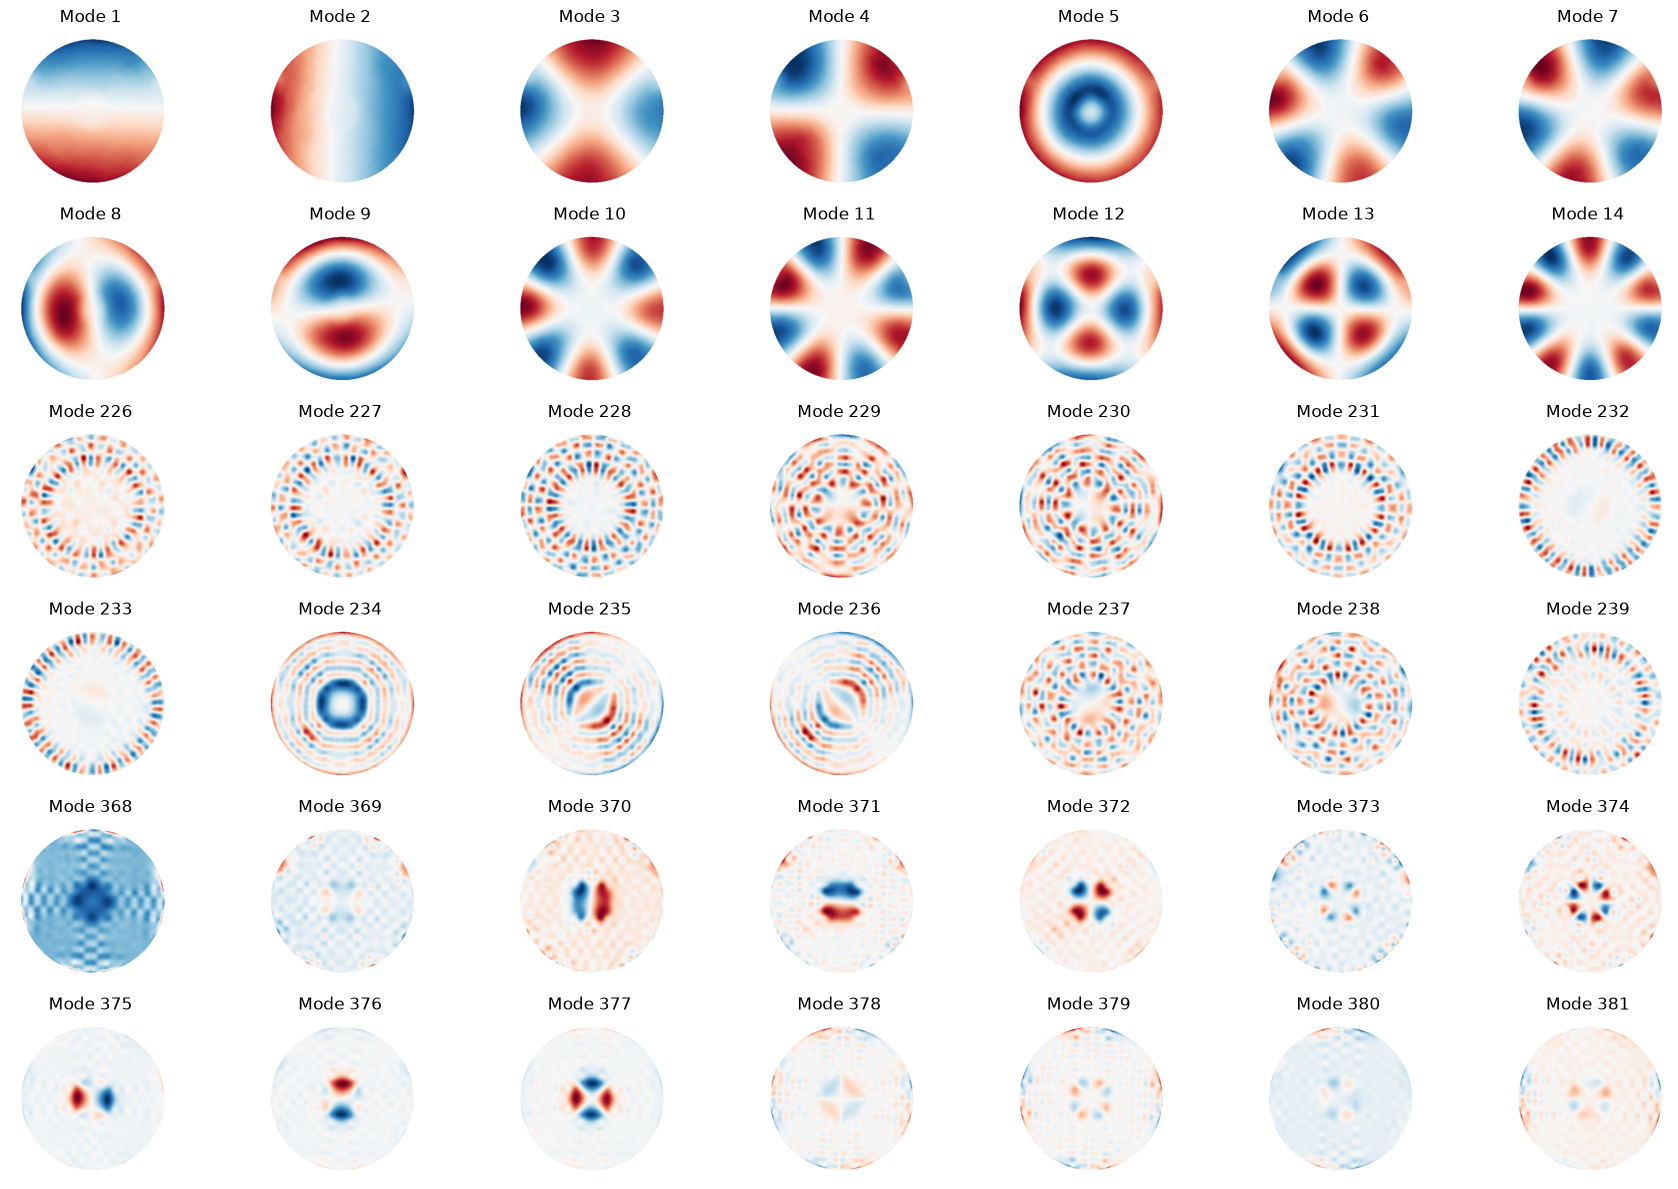

In [ ]:
m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_central_obstruction.npy')
iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/reordered_IFs.fits')
pupil_mask = (1-fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IFmask.fits')).astype(bool)
# m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_synthetic.npy')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_DM468_160pixels.fits')).astype(bool)
# m2c = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/simul_unobs_DM468_m2c.fits')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_unobs_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_unobs_DM468_160pixels.fits')).astype(bool)

kl_basis = (iffs @ m2c).T #iffs.T #
max_modes = 42
mode_display = np.zeros((max_modes, pupil_mask.shape[0], pupil_mask.shape[1]))
idx_mask = np.where(pupil_mask)
mode_ids = np.zeros(max_modes,dtype=int)

for i in range(max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = i+1
    mode_img[idx_mask] = kl_basis[i]
    mode_display[i] = mode_img
for i in range(max_modes//3,2*max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]//1.5-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img
for i in range(2*max_modes//3,max_modes):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img

# Plot the reshaped modes
n_rows = 6 #int(np.round(np.sqrt(max_modes)))
n_cols = 7 #int(np.ceil(max_modes / n_rows))
plt.figure(figsize=(18, 12))
for i in range(max_modes):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.ma.masked_array(mode_display[i],mask=1-pupil_mask),origin='lower',cmap='RdBu')
    plt.title(f'Mode {mode_ids[i]}')
    plt.axis('off')
plt.tight_layout()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[0 1 2 3 4 5 6 7]


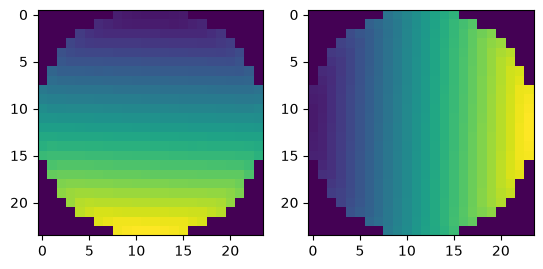

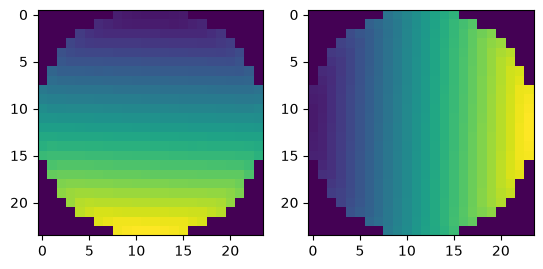

In [8]:
act_ids = np.argmax(iffs,axis=0)
X,Y = image_grid(pupil_mask.shape)
xx = X[pupil_mask]
yy = Y[pupil_mask]
xacts = xx[act_ids.astype(int)]
yacts = yy[act_ids.astype(int)]

dm468Map = np.array([
    [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0]
 ]
)

yact2d = np.zeros(dm468Map.shape)
yact2d[dm468Map.astype(bool)] = yacts
yact2d = yact2d.reshape(dm468Map.shape)

xact2d = np.zeros(dm468Map.shape)
xact2d[dm468Map.astype(bool)] = xacts
xact2d = xact2d.reshape(dm468Map.shape)

actIds = np.arange(468)
act_ids2d = np.zeros(dm468Map.shape)
act_ids2d[dm468Map.astype(bool)] = actIds
act_ids2d = act_ids2d.reshape(dm468Map.shape)

descramble2d = act_ids2d.copy()
for i in range(12,24):
    xcoords = xact2d[i,:]
    ids = act_ids2d[i,:] > 0
    sortids = np.argsort(xcoords[ids.astype(bool)])
    print(sortids)
    descramble2d[i,ids] = descramble2d[i,ids][sortids]

descramble = (descramble2d[dm468Map.astype(bool)]).astype(int)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(yact2d)
plt.subplot(1,2,2)
plt.imshow(xact2d)

dyact2d = np.zeros(dm468Map.shape)
dyact2d[dm468Map.astype(bool)] = yacts[descramble]
dyact2d = dyact2d.reshape(dm468Map.shape)

dxact2d = np.zeros(dm468Map.shape)
dxact2d[dm468Map.astype(bool)] = xacts[descramble]
dxact2d = dxact2d.reshape(dm468Map.shape)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(dyact2d)
plt.subplot(1,2,2)
plt.imshow(dxact2d)

# fits.writeto('/raid1/mmenessini/calibration/EKARUS/data/reordered_IFs.fits',iffs[:,descramble],overwrite=True)